# Synthetic Customer & Transaction Data — Method Comparison

Compares five synthesis strategies on the same seed data:

| # | Method | Synthesizer | Key property |
|---|---|---|---|
| 1 | **HMA + Gaussian Copula** | SDV default multi-table | Native FK integrity + cardinality |
| 2 | **Independent CTGAN** | CTGANSynthesizer per table | Better within-table distributions |
| 3 | **CTGAN + PAR Hybrid** | CTGAN (customers) + PAR (transactions) | Temporal realism + cross-table context |
| 4 | **Independent TVAE** | TVAESynthesizer per table | VAE: smooth marginals, stable training |
| 5 | **SmartNoise MST** | OpenDP MST (differentially private) | Formal (ε, δ)-DP privacy guarantee |

**Evaluation axes**
- Standard SDMetrics: Column Shapes, Column Pair Trends, Diagnostic
- **Cross-table correlation** (custom): Spearman(income → % investment products) — preserved?
- **Temporal realism** (custom): inter-arrival time KS test + amount autocorrelation

In [1]:
import sys, warnings
sys.path.insert(0, '.')
warnings.filterwarnings('ignore')

import time, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR    = Path('data')
REPORTS_DIR = Path('reports')
DATA_DIR.mkdir(exist_ok=True)
REPORTS_DIR.mkdir(exist_ok=True)

plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})
METHOD_COLORS = {
    'M1 – HMA GC':    '#4e79a7',
    'M2 – CTGAN':     '#f28e2b',
    'M3 – CTGAN+PAR': '#59a14f',
    'M4 – TVAE':      '#e15759',
    'M5 – SmartNoise': '#b07aa1',
    'Real':           '#bab0ac',
}
print('Ready.')

Ready.


---
## 1  Seed Data

500 customers with business-rule-driven demographics and transaction histories.  
This is the **real** dataset all three synthesizers learn from.

In [2]:
from src.seed_data import make_seed_data

real_data = make_seed_data(n_customers=1000)
for name, df in real_data.items():
    df.to_csv(DATA_DIR / f'real_{name}.csv', index=False)

real_2t = {k: real_data[k] for k in ('customers', 'transactions')}
df_c = real_data['customers']
df_t = real_data['transactions']

print(f'customers    : {len(df_c):,} rows')
print(f'transactions : {len(df_t):,} rows  (avg {len(df_t)/len(df_c):.1f} per customer)')
print(f'products     : {len(real_data["products"]):,} rows  (static catalog)')

customers    : 1,000 rows
transactions : 4,029 rows  (avg 4.0 per customer)
products     : 15 rows  (static catalog)


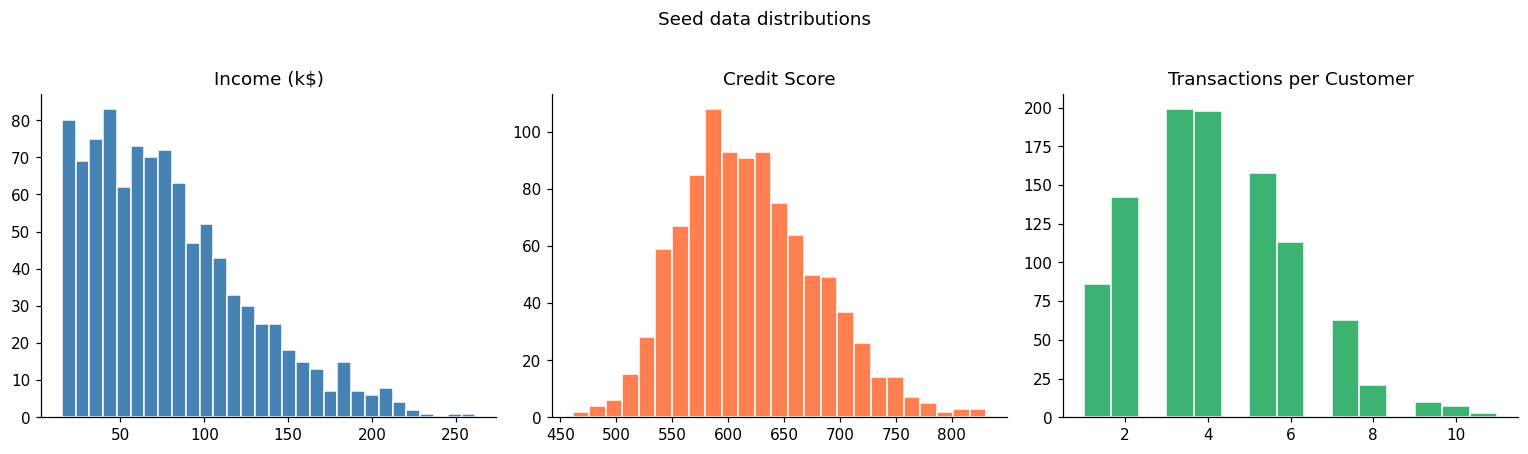

Pearson(income -> %investment): 0.459
Pearson(credit_score -> %investment): 0.316
Pearson(age -> %investment): -0.054


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(df_c['income'] / 1000, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Income (k$)')
axes[1].hist(df_c['credit_score'], bins=25, color='coral', edgecolor='white')
axes[1].set_title('Credit Score')
tc = df_t.groupby('customer_id').size()
axes[2].hist(tc, bins=15, color='mediumseagreen', edgecolor='white')
axes[2].set_title('Transactions per Customer')

plt.suptitle('Seed data distributions', y=1.02)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'seed_overview.png', bbox_inches='tight')
plt.show()

# Key signal the synthesizers need to preserve
pct_inv = df_t.groupby('customer_id').apply(
    lambda g: (g['product_category'] == 'Investment').mean()
).rename('pct_investment')
merged = df_c.set_index('customer_id').join(pct_inv)
for feat in ['income', 'credit_score', 'age']:
    corr = merged[feat].corr(merged['pct_investment'])
    print(f'Pearson({feat} -> %investment): {corr:.3f}')

In [4]:
from src.metrics_extended import cross_table_correlation

real_ct = cross_table_correlation(df_c, df_t)
print('Real Spearman correlations (feature → % product category):')
real_ct.pivot(index='feature', columns='category', values='spearman_r').round(3)

Real Spearman correlations (feature → % product category):


category,Banking,Credit,Insurance,Investment
feature,,,,
age,-0.047,-0.011,0.128,-0.043
credit_score,-0.414,0.581,-0.152,0.411
income,-0.480,0.430,-0.083,0.588


---
## 2  Schema: Auto-detected vs Hand-crafted

SDV's `detect_from_dataframes()` infers column types and FK relationships automatically.
The cell below runs auto-detection on the real seed data and compares it column-by-column
against the hand-crafted schema in `src/schema.py`.

**What auto-detection gets right**
- Primary keys (`customer_id`, `transaction_id`, `product_id`)
- Most categorical columns (`gender`, `education`, `occupation`, `channel`, `status`, …)
- Numerical columns (`income`, `credit_score`, `amount`, `tenure_years`, …)
- Datetime format — correctly infers `transaction_date` as `datetime` with `"%Y-%m-%d"`
- FK relationships — infers both `customers → transactions` and `products → transactions`
  from matching ID column names

**What auto-detection gets wrong or misses**

| Column | Auto-detected | Hand-crafted | Why it matters |
|---|---|---|---|
| `products.is_premium` | `categorical` | `boolean` | Synthesised as strings `True`/`False`, not proper booleans |
| `customers.is_churned` | `categorical` | `boolean` | Boolean semantics lost; downstream type errors |
| `transactions.is_first_product` | `categorical` | `boolean` | Same |
| `customers.num_dependents` | `categorical` | `numerical (Int64)` | Treated as a label; loses integer ordering and range |
| Integer numerics (`age`, `credit_score`, `num_dependents`) | `numerical` (no repr) | `numerical + Int64` | Without `Int64`, SDV may generate floats like `42.7` for age |
| Float numerics (`income`, `amount`, `tenure_years`) | `numerical` (no repr) | `numerical + Float` | Explicit declaration prevents regressions if SDV changes defaults |
| All ID columns | `id` (no format) | `id + regex_format` | Without regex, synthesised IDs break `C[0-9]{5}` / `T[0-9]{6}` patterns |
| `transactions.product_id` | `id` (FK to products) | `categorical` (2-table schema) | Auto-detect enforces FK integrity to products; hand-crafted intentionally decouples it so product IDs are learned as a distribution |

In [5]:
import json
from sdv.metadata import MultiTableMetadata
from src.schema import build_metadata_2table, build_metadata

# ── Auto-detected schema ──────────────────────────────────────────────────────
auto_meta = MultiTableMetadata()
auto_meta.detect_from_dataframes(real_data)
auto_dict = auto_meta.to_dict()

with open(REPORTS_DIR / 'auto_detected_metadata.json', 'w') as f:
    json.dump(auto_dict, f, indent=2)

# Hand-crafted: use 2-table for customers/transactions, full 3-table for products
hand_2t   = build_metadata_2table().to_dict()
hand_full = build_metadata().to_dict()
hand_by_table = {
    'customers':    hand_2t['tables']['customers']['columns'],
    'transactions': hand_2t['tables']['transactions']['columns'],
    'products':     hand_full['tables']['products']['columns'],
}

# ── Render full sdtype string including all details ───────────────────────────
def fmt(col_props: dict) -> str:
    if not col_props:
        return '(not in schema)'
    parts = [col_props.get('sdtype', '?')]
    if col_props.get('computer_representation'):
        parts.append(col_props['computer_representation'])
    if col_props.get('regex_format'):
        parts.append(f'regex={col_props["regex_format"]}')
    if col_props.get('datetime_format'):
        parts.append(col_props['datetime_format'])
    return '  '.join(parts)

# ── Build comparison rows ─────────────────────────────────────────────────────
TABLE_NOTES = {
    'products': '(excluded from 2-table training schema — static lookup only)'
}

rows = []
for table in ('customers', 'transactions', 'products'):
    auto_cols = auto_dict['tables'].get(table, {}).get('columns', {})
    hand_cols = hand_by_table.get(table, {})
    for col in sorted(set(auto_cols) | set(hand_cols)):
        a      = auto_cols.get(col, {})
        h      = hand_cols.get(col, {})
        a_str  = fmt(a)
        h_str  = fmt(h)
        a_type = a.get('sdtype', '')
        h_type = h.get('sdtype', '')

        if a_str == h_str:
            status = '✓  exact'
        elif a_type == h_type:
            status = '~  partial'   # same sdtype, missing detail (repr / regex / format)
        else:
            status = '✗  mismatch'  # wrong sdtype entirely

        rows.append({
            'table':         table + (' *' if table == 'products' else ''),
            'column':        col,
            'auto_detected': a_str,
            'hand_crafted':  h_str,
            'status':        status,
        })

cmp_schema = pd.DataFrame(rows)

# ── Style: colour by status ───────────────────────────────────────────────────
STATUS_COLORS = {
    '✓  exact':    'background-color: #f0fdf4',   # green tint
    '~  partial':  'background-color: #fef9c3',   # yellow tint
    '✗  mismatch': 'background-color: #fee2e2',   # red tint
}

def _color_row(row):
    c = STATUS_COLORS.get(row['status'], '')
    return [c] * len(row)

display(
    cmp_schema.style
        .apply(_color_row, axis=1)
        .set_caption(
            'Schema comparison  |  ✓ exact match  ~  same sdtype, missing detail  ✗ wrong type\n'
            '* products excluded from 2-table training schema (static lookup)'
        )
        .set_properties(**{'font-size': '12px'})
        .hide(axis='index')
)

exact    = (cmp_schema['status'] == '✓  exact').sum()
partial  = (cmp_schema['status'] == '~  partial').sum()
mismatch = (cmp_schema['status'] == '✗  mismatch').sum()
print(f'✓ exact: {exact}   ~ partial (missing detail): {partial}   ✗ mismatch: {mismatch}')

table,column,auto_detected,hand_crafted,status
customers,age,numerical,numerical Int64,~ partial
customers,credit_score,numerical,numerical Int64,~ partial
customers,customer_id,id,id regex=C[0-9]{5},~ partial
customers,education,categorical,categorical,✓ exact
customers,gender,categorical,categorical,✓ exact
customers,income,numerical,numerical Float,~ partial
customers,is_churned,categorical,boolean,✗ mismatch
customers,marital_status,categorical,categorical,✓ exact
customers,num_dependents,categorical,numerical Int64,✗ mismatch
customers,occupation,categorical,categorical,✓ exact


✓ exact: 11   ~ partial (missing detail): 11   ✗ mismatch: 5


---
## 3  Method 1 — HMA + Gaussian Copula

SDV's default multi-table synthesizer. Trains Gaussian Copula on each table, then learns the
**extension model**: how many child rows each parent has and what their aggregate stats look like.
This preserves the transaction-count-per-customer distribution natively.

Schema: **2-table** (customers → transactions). `products` is a static lookup, not synthesized.

In [6]:
from src.methods import train_hma_gc, generate_hma_gc

t0 = time.time()
m1 = train_hma_gc(real_2t, save=True)
print(f'M1 train: {time.time()-t0:.1f}s')

t0 = time.time()
s1 = generate_hma_gc(m1, n_customers=1000, seed_size=500)
print(f'M1 sample: {time.time()-t0:.1f}s | customers={len(s1["customers"]):,}  transactions={len(s1["transactions"]):,}')

s1['customers'].to_csv(DATA_DIR / 'm1_customers.csv', index=False)
s1['transactions'].to_csv(DATA_DIR / 'm1_transactions.csv', index=False)
orphans = s1['transactions'][~s1['transactions']['customer_id'].isin(s1['customers']['customer_id'])]
print(f'Orphan FK rows: {len(orphans)}  (must be 0)')

Preprocess Tables:   0%|          | 0/2 [00:00<?, ?it/s]

Preprocess Tables:  50%|█████     | 1/2 [00:00<00:00,  7.08it/s]

Preprocess Tables: 100%|██████████| 2/2 [00:00<00:00,  7.64it/s]

Preprocess Tables: 100%|██████████| 2/2 [00:00<00:00,  7.53it/s]


Learning relationships:


...

Modeling Tables:   0%|          | 0/2 [00:00<?, ?it/s]

Modeling Tables:  50%|█████     | 1/2 [00:00<00:00,  1.44it/s]

Modeling Tables: 100%|██████████| 2/2 [00:00<00:00,  2.82it/s]

M1 train: 7.7s


M1 sample: 71.1s | customers=2,000  transactions=8,058
Orphan FK rows: 0  (must be 0)


---
## 4  Method 2 — Independent CTGAN

CTGANSynthesizer trained separately on each table.  
CTGAN uses **mode-specific normalisation** for numericals and a **conditional generator** for
categoricals, avoiding mode collapse — better marginal distributions than Gaussian Copula.

**Limitation:** transactions are sampled independently; cross-table correlations (income → product
category) are NOT captured at sampling time.  Cardinality is preserved by re-sampling transaction
counts from the real distribution.

In [7]:
from src.methods import train_ctgan, generate_ctgan

t0 = time.time()
m2 = train_ctgan(real_2t, epochs=300, save=True)
print(f'M2 train: {time.time()-t0:.1f}s')

t0 = time.time()
s2 = generate_ctgan(m2, real_transactions=df_t, n_customers=1000)
print(f'M2 sample: {time.time()-t0:.1f}s | customers={len(s2["customers"]):,}  transactions={len(s2["transactions"]):,}')

s2['customers'].to_csv(DATA_DIR / 'm2_customers.csv', index=False)
s2['transactions'].to_csv(DATA_DIR / 'm2_transactions.csv', index=False)
orphans = s2['transactions'][~s2['transactions']['customer_id'].isin(s2['customers']['customer_id'])]
print(f'Orphan FK rows: {len(orphans)}')

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f1ea04f1750>
Traceback (most recent call last):
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f1ea04f1750>
Traceback (most recent call last):
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f1ea04f1750>
Traceback (most recent call last):
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f1ea04f1750>
Traceback (most recent call last):
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f1ea04f1750>
Traceback (most recent call last):
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


...

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f1e9d5e44c0>
Traceback (most recent call last):
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f1e9d5e44c0>
Traceback (most recent call last):
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f1e9d5e44c0>
Traceback (most recent call last):
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


M2 train: 109.6s


M2 sample: 55.8s | customers=1,000  transactions=4,079
Orphan FK rows: 0


---
## 5  Method 3 — CTGAN + PAR Hybrid

- **CTGAN** for customers (same as M2).
- **PARSynthesizer** (RNN) for transactions, ordered by `transaction_date`.
  Customer features `income` and `credit_score` are passed as `context_columns` so PAR
  learns *"high-income customer → investment products in sequence"*.
- **FK join:** PAR generates sequences with its own sampled context. Each PAR sequence is
  matched to the nearest synthetic customer by `(income, credit_score)` via k-NN.

This is the only method that models temporal ordering explicitly.

In [8]:
from src.methods import train_hybrid, generate_hybrid

t0 = time.time()
m3 = train_hybrid(real_2t, ctgan_epochs=300, par_epochs=128, save=True)
print(f'M3 train: {time.time()-t0:.1f}s')

t0 = time.time()
s3 = generate_hybrid(m3, n_customers=1000)
print(f'M3 sample: {time.time()-t0:.1f}s | customers={len(s3["customers"]):,}  transactions={len(s3["transactions"]):,}')

s3['customers'].to_csv(DATA_DIR / 'm3_customers.csv', index=False)
s3['transactions'].to_csv(DATA_DIR / 'm3_transactions.csv', index=False)
orphans = s3['transactions'][~s3['transactions']['customer_id'].isin(s3['customers']['customer_id'])]
print(f'Orphan FK rows: {len(orphans)}')

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f1faa0cbd90>
Traceback (most recent call last):
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f1ea04f1630>
Traceback (most recent call last):
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f1ea04f1630>
Traceback (most recent call last):
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f1ea04f1630>
Traceback (most recent call last):
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f1ea04f1630>
Traceback (most recent call last):
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


...

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f1ea04f1630>
Traceback (most recent call last):
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f1ea04f1630>
Traceback (most recent call last):
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f1ea04f1630>
Traceback (most recent call last):
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


M3 train: 303.2s


M3 sample: 23.3s | customers=1,000  transactions=4,982
Orphan FK rows: 0


---
## 6  Method 4 — Independent TVAE

**TVAESynthesizer** trained separately on each table (like M2) — but a **variational autoencoder** instead of a GAN. TVAE typically yields smoother numeric marginals and trains more stably than CTGAN, at the cost of sometimes blurrier categorical boundaries.

Cardinality is re-sampled from the real distribution; cross-table correlations are **not** modelled at sampling time (same limitation as M2). All methods are fitted under SDV **CAG constraints** (`src/constraints.py`): `FixedCombinations` (product↔category) + `ScalarInequality` (amount ≥ 0) on transactions, and `FixedIncrements` (whole dependents) + `ScalarRange` (credit_score ∈ [300, 850]) + `Inequality` (tenure ≤ age) on customers. PAR (M3) can't take `FixedCombinations`, so it keeps a few product/category drifts.

In [9]:
from src.methods import train_tvae, generate_tvae

t0 = time.time()
m4 = train_tvae(real_2t, epochs=300, save=True)
print(f'M4 train: {time.time()-t0:.1f}s')

t0 = time.time()
s4 = generate_tvae(m4, real_transactions=df_t, n_customers=1000)
print(f'M4 sample: {time.time()-t0:.1f}s | customers={len(s4["customers"]):,}  transactions={len(s4["transactions"]):,}')

s4['customers'].to_csv(DATA_DIR / 'm4_customers.csv', index=False)
s4['transactions'].to_csv(DATA_DIR / 'm4_transactions.csv', index=False)
orphans = s4['transactions'][~s4['transactions']['customer_id'].isin(s4['customers']['customer_id'])]
print(f'Orphan FK rows: {len(orphans)}')

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f1e9d5e43a0>
Traceback (most recent call last):
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f1fa9e769e0>
Traceback (most recent call last):
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f1fa9e769e0>
Traceback (most recent call last):
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f1fa9e769e0>
Traceback (most recent call last):
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f1fa9e769e0>
Traceback (most recent call last):
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


...

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f1e9d5e40d0>
Traceback (most recent call last):
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f1e9d5e40d0>
Traceback (most recent call last):
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f1e9d5e40d0>
Traceback (most recent call last):
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/dylannguyen/anaconda3/envs/py3-TF2/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


M4 train: 62.2s


M4 sample: 44.6s | customers=1,000  transactions=4,006
Orphan FK rows: 0


---
## 7  Method 5 — SmartNoise MST (differential privacy)

**SmartNoise** (OpenDP) synthesises each table under a formal **(ε, δ)-differential-privacy** guarantee — the one property no SDV method provides. **MST** is a marginal-based DP synthesizer: it spends the ε budget measuring noisy low-order marginals, then samples from a graphical model.

- Fit per table (like M2/M4); IDs dropped before fitting and regenerated after.
- `transaction_date` encoded as a day-offset; business rules restored by **post-processing** (clip to valid domains, map `product_id`→category) — DP synthesizers don't take SDV constraints, and post-processing a DP output preserves the guarantee.
- Budget: `epsilon` per table (≈ 2·ε total across the two tables).

In [10]:
from src.smartnoise_method import train_smartnoise, generate_smartnoise

t0 = time.time()
m5 = train_smartnoise(real_data, epsilon=3.0)
print(f'M5 train: {time.time()-t0:.1f}s  (ε=3.0 per table)')

t0 = time.time()
s5 = generate_smartnoise(m5, real_transactions=df_t, n_customers=1000)
print(f'M5 sample: {time.time()-t0:.1f}s | customers={len(s5["customers"]):,}  transactions={len(s5["transactions"]):,}')

s5['customers'].to_csv(DATA_DIR / 'm5_customers.csv', index=False)
s5['transactions'].to_csv(DATA_DIR / 'm5_transactions.csv', index=False)
orphans = s5['transactions'][~s5['transactions']['customer_id'].isin(s5['customers']['customer_id'])]
print(f'Orphan FK rows: {len(orphans)}')

Spent 0.5 epsilon on preprocessor, leaving 2.5 for training


WARNING	jax._src.xla_bridge:xla_bridge.py:_suggest_missing_backends()- An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


Spent 0.5 epsilon on preprocessor, leaving 2.5 for training


M5 train: 40.7s  (ε=3.0 per table)


M5 sample: 2.0s | customers=1,000  transactions=4,139
Orphan FK rows: 0


---
## 8  Evaluation — All Metrics

Runs SDMetrics quality/diagnostic reports + the two custom metrics across all four methods.

In [11]:
from src.metrics_extended import compare_methods

synthetic_datasets = {
    'M1 – HMA GC':    s1,
    'M2 – CTGAN':     s2,
    'M3 – CTGAN+PAR': s3,
    'M4 – TVAE':      s4,
    'M5 – SmartNoise': s5,
}

print('Running full comparison …')
cmp = compare_methods(real_2t, synthetic_datasets)
cmp.to_csv(REPORTS_DIR / 'method_comparison.csv')
cmp

Running full comparison …
  Evaluating: M1 – HMA GC …


  Evaluating: M2 – CTGAN …


  Evaluating: M3 – CTGAN+PAR …


  Evaluating: M4 – TVAE …


  Evaluating: M5 – SmartNoise …


,quality_score,diagnostic_score,cust_column_shapes,cust_pair_trends,txn_column_shapes,cross_table_mad,cross_table_max_err,ia_ks_pvalue,ia_ks_stat,autocorr_mae,syn_ia_mean
method,,,,,,,,,,,
M1 – HMA GC,0.8511,1.0000,0.9265,0.7204,0.8184,0.2420,0.5153,0.0000,0.2186,0.0758,147.37
M2 – CTGAN,0.8398,1.0000,0.8417,0.5444,0.8510,0.2806,0.6150,0.1426,0.0293,0.0632,249.68
M3 – CTGAN+PAR,0.5440,0.7649,0.7981,0.5403,0.7394,0.1950,0.5203,0.0000,0.4416,0.1240,81.05
M4 – TVAE,0.8257,1.0000,0.7896,0.6831,0.7876,0.2880,0.5997,0.0000,0.3032,0.0223,310.32
M5 – SmartNoise,0.8869,0.9998,0.9059,0.6796,0.8797,0.2969,0.5987,0.0000,0.7620,0.0045,50.22


---
### Constraint adherence

Every method is fitted under the SDV CAG constraints in `src/constraints.py`. The table below confirms each rule holds in the generated data. **M3/PAR** is the one exception on `prod/cat drift` — `FixedCombinations` is incompatible with PAR's sequence model, so it keeps a few product/category mismatches while every other rule still holds.

In [12]:
def _constraint_report(name, s):
    cu, tr = s['customers'], s['transactions']
    return {
        'method':            name,
        'orphan_fk':         int((~tr['customer_id'].isin(cu['customer_id'])).sum()),
        'prod/cat drift':    int((tr.groupby('product_id')['product_category'].nunique() > 1).sum()),
        'deps whole':        bool((cu['num_dependents'] == cu['num_dependents'].round()).all()),
        'credit in [300,850]': bool(cu['credit_score'].between(300, 850).all()),
        'tenure <= age':     bool((cu['tenure_years'] <= cu['age']).all()),
        'amount >= 0':       bool((tr['amount'] >= 0).all()),
    }

adherence = pd.DataFrame(
    [_constraint_report(n, s) for n, s in synthetic_datasets.items()]
).set_index('method')
adherence

,orphan_fk,prod/cat drift,deps whole,"credit in [300,850]",tenure <= age,amount >= 0
method,,,,,,
M1 – HMA GC,0,0,True,True,True,True
M2 – CTGAN,0,0,True,True,True,True
M3 – CTGAN+PAR,0,15,True,True,True,True
M4 – TVAE,0,0,True,True,True,True
M5 – SmartNoise,0,0,True,True,True,True


---
## 9  Cross-Table Correlation — Detail

Spearman correlation between customer features (income, credit_score, age) and their
per-customer product-category mix (% Banking / Credit / Insurance / Investment).

The heatmaps show whether each method preserves the real correlation structure.  
**MAD (mean absolute difference)** is the scalar summary — lower = better.

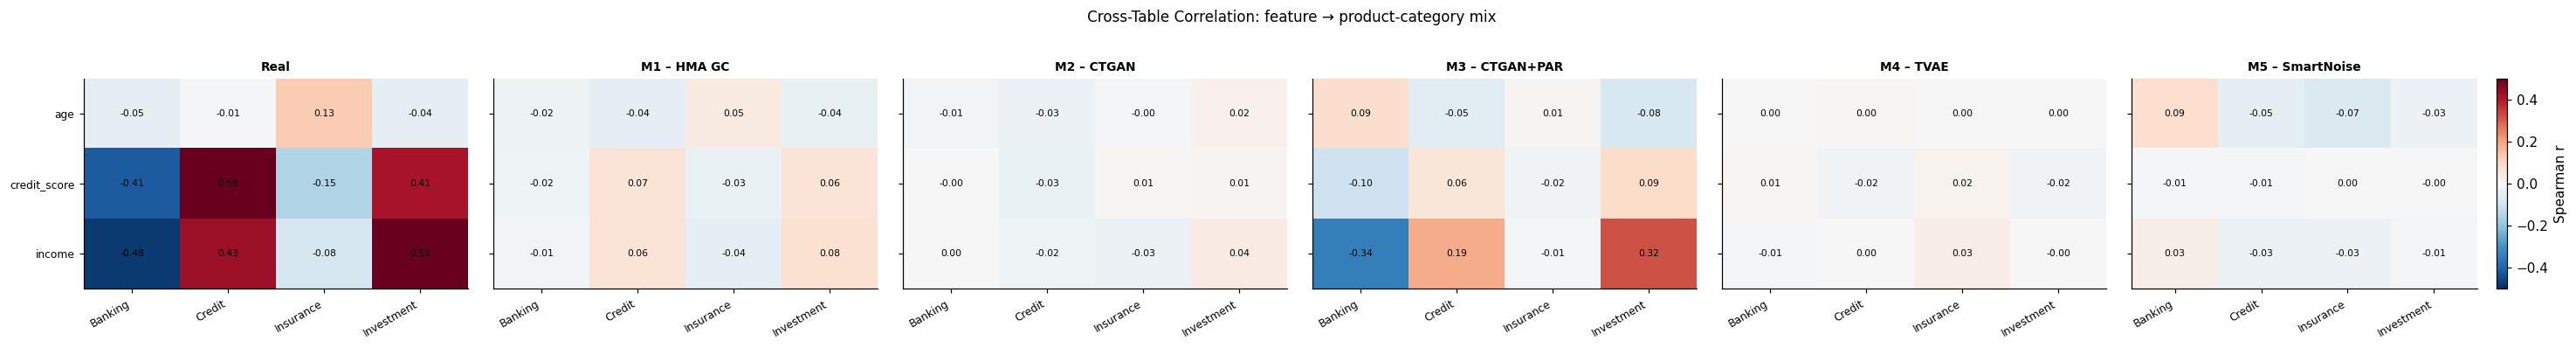

Cross-table MAD (lower = better):
  M1 – HMA GC           MAD=0.2420  max=0.5153
  M2 – CTGAN            MAD=0.2806  max=0.6150
  M3 – CTGAN+PAR        MAD=0.1950  max=0.5203
  M4 – TVAE             MAD=0.2880  max=0.5997
  M5 – SmartNoise       MAD=0.2969  max=0.5987


In [13]:
from src.metrics_extended import cross_table_score

n_panels = len(synthetic_datasets) + 1
fig, axes = plt.subplots(1, n_panels, figsize=(4.5 * n_panels, 3.5), sharey=True)
all_sets = [('Real', df_c, df_t)] + [(n, s['customers'], s['transactions'])
                                      for n, s in synthetic_datasets.items()]

for ax, (name, cdf, tdf) in zip(axes, all_sets):
    corr  = cross_table_correlation(cdf, tdf)
    pivot = corr.pivot(index='feature', columns='category', values='spearman_r')
    im = ax.imshow(pivot.values, cmap='RdBu_r', vmin=-0.5, vmax=0.5, aspect='auto')
    ax.set_xticks(range(len(pivot.columns)));  ax.set_xticklabels(pivot.columns, rotation=30, ha='right', fontsize=8)
    ax.set_yticks(range(len(pivot.index)));    ax.set_yticklabels(pivot.index, fontsize=8)
    ax.set_title(name, fontweight='bold', fontsize=9)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            ax.text(j, i, f'{pivot.values[i,j]:.2f}', ha='center', va='center', fontsize=7)

plt.colorbar(im, ax=axes[-1], fraction=0.05, label='Spearman r')
fig.suptitle('Cross-Table Correlation: feature → product-category mix', y=1.02, fontsize=11)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'cross_table_heatmap.png', bbox_inches='tight')
plt.show()

print('Cross-table MAD (lower = better):')
for name, s in synthetic_datasets.items():
    sc = cross_table_score(df_c, df_t, s['customers'], s['transactions'])
    print(f'  {name:<20}  MAD={sc["mean_abs_delta"]:.4f}  max={sc["max_abs_delta"]:.4f}')

---
### Within-table correlation (customers)

Unlike the cross-table signal (feature → product category, which is weak for every method), the **within-customer** correlation structure — `income ↔ credit_score ↔ age ↔ tenure ↔ dependents` — is where the methods clearly differ. The heatmaps show each method's Pearson correlation matrix vs **Real**; the **MAE** (mean absolute error over the off-diagonal pairs, lower = better) scores how faithfully each reproduces that structure.

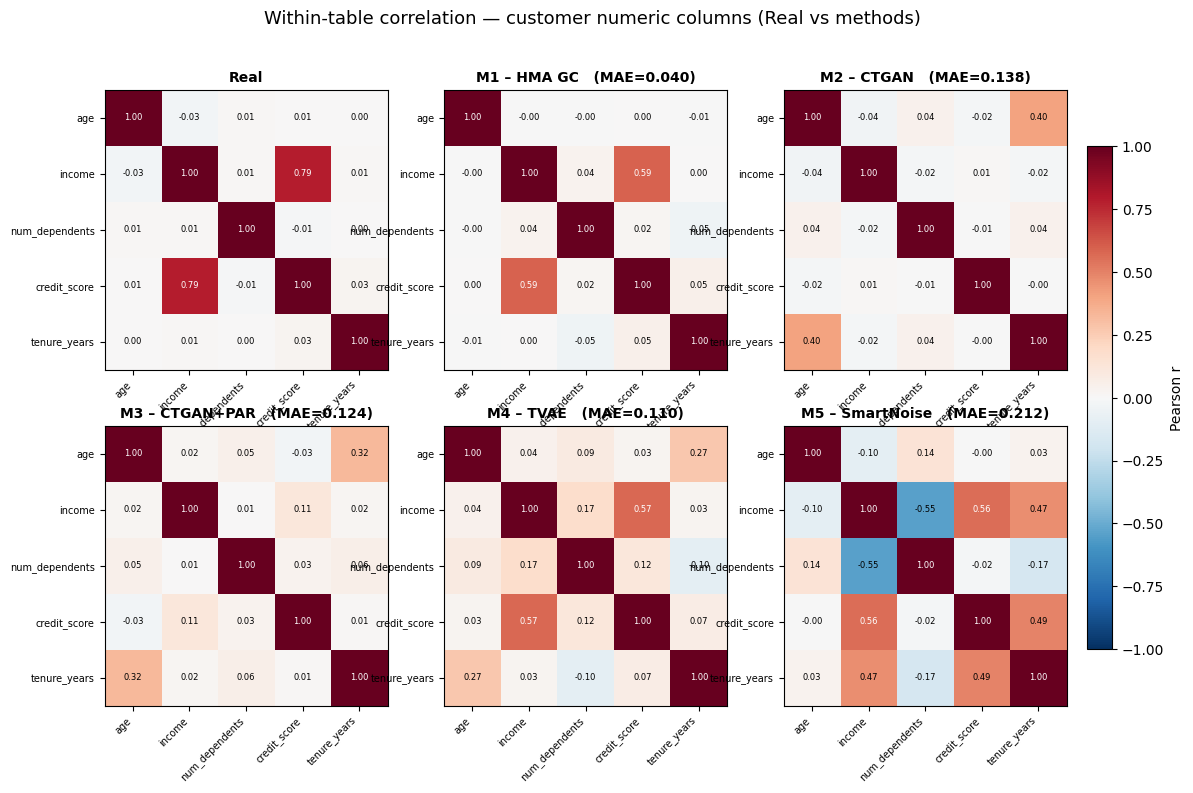

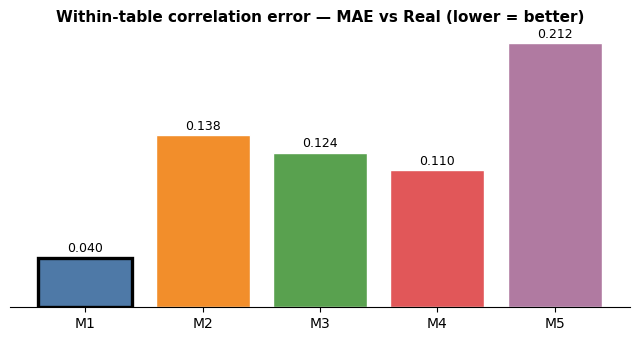

Within-table (customer) correlation MAE vs Real (lower = better):
  M1 – HMA GC        0.0396
  M2 – CTGAN         0.1378
  M3 – CTGAN+PAR     0.1240
  M4 – TVAE          0.1098
  M5 – SmartNoise    0.2116


In [ ]:
# Within-table (customer) correlation structure — Real vs each method
from itertools import product as _prod
corr_cols = ['age', 'income', 'num_dependents', 'credit_score', 'tenure_years']
def _corr(dfc): return dfc[corr_cols].corr(method='pearson')

real_corr = _corr(df_c)
iu = np.triu_indices(len(corr_cols), 1)          # off-diagonal pairs only
panels = [('Real', df_c)] + [(n, s['customers']) for n, s in synthetic_datasets.items()]

# Figure 1 — correlation matrices (2 x 3)
fig, axes = plt.subplots(2, 3, figsize=(13, 8)); axes = axes.ravel()
for ax, (name, dfc) in zip(axes, panels):
    M = _corr(dfc).values
    im = ax.imshow(M, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    mae = np.abs(M - real_corr.values)[iu].mean()
    ax.set_title(name if name == 'Real' else f'{name}   (MAE={mae:.3f})',
                 fontsize=10, fontweight='bold')
    ax.set_xticks(range(len(corr_cols))); ax.set_xticklabels(corr_cols, rotation=45, ha='right', fontsize=7)
    ax.set_yticks(range(len(corr_cols))); ax.set_yticklabels(corr_cols, fontsize=7)
    for i, j in _prod(range(len(corr_cols)), repeat=2):
        ax.text(j, i, f'{M[i,j]:.2f}', ha='center', va='center', fontsize=6,
                color='white' if abs(M[i,j]) > 0.55 else 'black')
for k in range(len(panels), len(axes)): axes[k].axis('off')
fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02, label='Pearson r')
fig.suptitle('Within-table correlation — customer numeric columns (Real vs methods)', fontsize=13)
plt.savefig(REPORTS_DIR / 'in_table_correlation.png', bbox_inches='tight'); plt.show()

# Figure 2 — correlation-fidelity ranking (lower MAE = better)
maes = {n: float(np.abs(_corr(s['customers']).values - real_corr.values)[iu].mean())
        for n, s in synthetic_datasets.items()}
fig, ax = plt.subplots(figsize=(8, 3.6))
names = list(maes); bars = ax.bar([f'M{i+1}' for i in range(len(names))],
                                   [maes[n] for n in names],
                                   color=[METHOD_COLORS[n] for n in names], edgecolor='white')
best_i = int(np.argmin([maes[n] for n in names]))
bars[best_i].set_edgecolor('black'); bars[best_i].set_linewidth(2.4)
ax.bar_label(bars, fmt='%.3f', fontsize=9, padding=2)
ax.set_title('Within-table correlation error — MAE vs Real (lower = better)', fontsize=11, fontweight='bold')
ax.set_yticks([]); [ax.spines[s].set_visible(False) for s in ('top','right','left')]
plt.savefig(REPORTS_DIR / 'in_table_corr_error.png', bbox_inches='tight'); plt.show()

print('Within-table (customer) correlation MAE vs Real (lower = better):')
for n in names: print(f'  {n:<18} {maes[n]:.4f}')

---
## 10  Temporal Realism — Detail

| Metric | How | Better |
|---|---|---|
| **Inter-arrival KS p-value** | KS test on days-between-consecutive-transactions | Higher |
| **Amount autocorr MAE** | |real_lag1_autocorr − syn_lag1_autocorr| | Lower |

Only PAR (M3) explicitly models the ordering of transactions within a customer's history.

Real: inter-arrival mean=254.1d  median=191.0d  autocorr=-0.2624


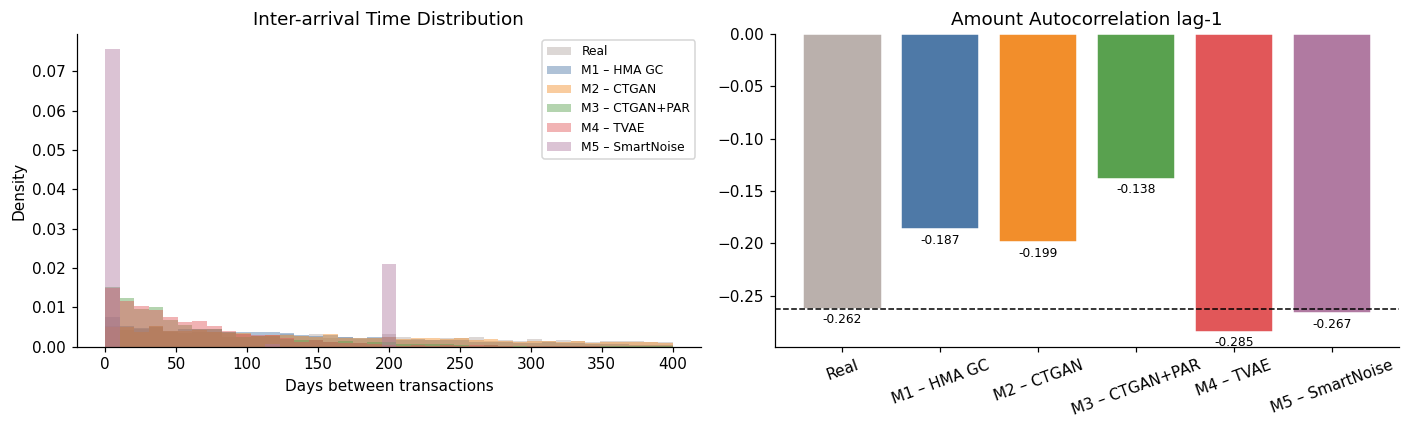


Temporal scores:


  M1 – HMA GC           KS p=0.0000  autocorr_MAE=0.0758  ia_mean=147.4d


  M2 – CTGAN            KS p=0.1426  autocorr_MAE=0.0632  ia_mean=249.7d
  M3 – CTGAN+PAR        KS p=0.0000  autocorr_MAE=0.1240  ia_mean=81.0d


  M4 – TVAE             KS p=0.0000  autocorr_MAE=0.0223  ia_mean=310.3d


  M5 – SmartNoise       KS p=0.0000  autocorr_MAE=0.0045  ia_mean=50.2d


In [14]:
from src.metrics_extended import temporal_stats, temporal_score

real_ts = temporal_stats(df_t)
print(f'Real: inter-arrival mean={real_ts["inter_arrival_mean"]:.1f}d  '
      f'median={real_ts["inter_arrival_median"]:.1f}d  '
      f'autocorr={real_ts["amount_autocorr_mean"]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Inter-arrival histograms
bins = np.linspace(0, 400, 40)
axes[0].hist(real_ts['inter_arrival_values'], bins=bins, density=True,
             alpha=0.5, color=METHOD_COLORS['Real'], label='Real')
for name, s in synthetic_datasets.items():
    st = temporal_stats(s['transactions'])
    axes[0].hist(st['inter_arrival_values'], bins=bins, density=True,
                 alpha=0.45, color=METHOD_COLORS[name], label=name)
axes[0].set_xlabel('Days between transactions');  axes[0].set_ylabel('Density')
axes[0].set_title('Inter-arrival Time Distribution');  axes[0].legend(fontsize=8)

# Autocorrelation bar
names_bar  = ['Real'] + list(synthetic_datasets.keys())
ac_vals    = [real_ts['amount_autocorr_mean']] + [
    temporal_stats(s['transactions'])['amount_autocorr_mean']
    for s in synthetic_datasets.values()]
bars = axes[1].bar(names_bar, ac_vals, color=[METHOD_COLORS[n] for n in names_bar], edgecolor='white')
axes[1].bar_label(bars, fmt='%.3f', padding=3, fontsize=8)
axes[1].axhline(real_ts['amount_autocorr_mean'], color='black', linestyle='--', linewidth=1)
axes[1].set_title('Amount Autocorrelation lag-1')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'temporal_realism.png', bbox_inches='tight')
plt.show()

print('\nTemporal scores:')
for name, s in synthetic_datasets.items():
    ts = temporal_score(df_t, s['transactions'])
    print(f'  {name:<20}  KS p={ts["ia_ks_pvalue"]:.4f}  autocorr_MAE={ts["autocorr_mae"]:.4f}  ia_mean={ts["syn_ia_mean"]:.1f}d')

---
## 11  Comparison Dashboard

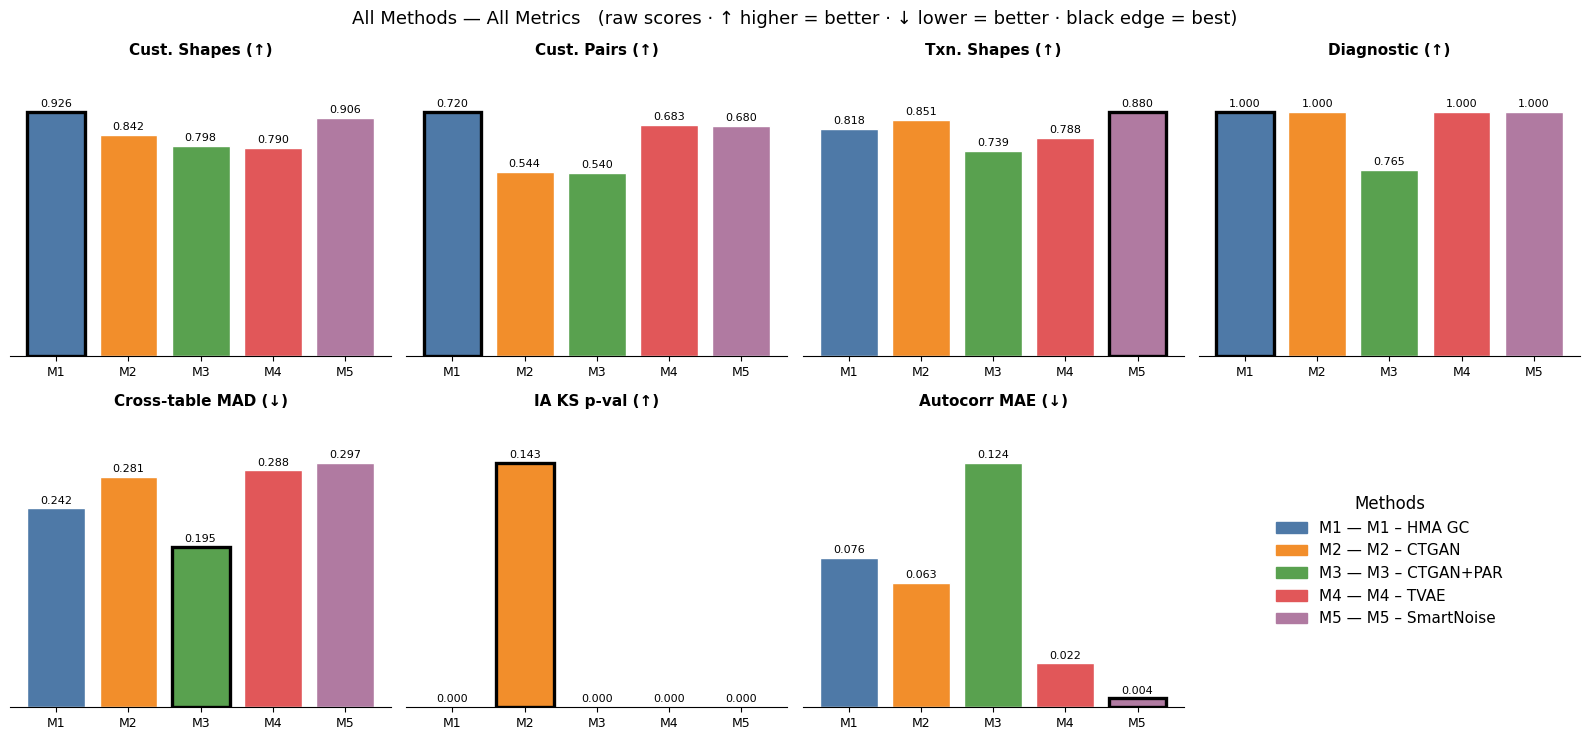

Metric                        M1        M2        M3        M4        M5   Best
-------------------------------------------------------------------------------
Cust. Shapes (↑)           0.926     0.842     0.798     0.790     0.906   M1
Cust. Pairs (↑)            0.720     0.544     0.540     0.683     0.680   M1
Txn. Shapes (↑)            0.818     0.851     0.739     0.788     0.880   M5
Diagnostic (↑)             1.000     1.000     0.765     1.000     1.000   M1
Cross-table MAD (↓)        0.242     0.281     0.195     0.288     0.297   M3
IA KS p-val (↑)            0.000     0.143     0.000     0.000     0.000   M2
Autocorr MAE (↓)           0.076     0.063     0.124     0.022     0.004   M5


In [15]:
metrics_cfg = {
    'Cust. Shapes (↑)':    ('cust_column_shapes', True),
    'Cust. Pairs (↑)':     ('cust_pair_trends',   True),
    'Txn. Shapes (↑)':     ('txn_column_shapes',  True),
    'Diagnostic (↑)':      ('diagnostic_score',   True),
    'Cross-table MAD (↓)': ('cross_table_mad',    False),
    'IA KS p-val (↑)':     ('ia_ks_pvalue',       True),
    'Autocorr MAE (↓)':    ('autocorr_mae',       False),
}
method_names = list(synthetic_datasets.keys())
short = {m: f'M{i+1}' for i, m in enumerate(method_names)}   # M1..M5 tick labels

# One small panel per metric — each keeps its own (raw) y-scale, so metrics are
# easy to read individually instead of being squashed onto one shared axis.
fig, axes = plt.subplots(2, 4, figsize=(16, 7.5))
axes = axes.ravel()
for ax, (label, (col, higher)) in zip(axes, metrics_cfg.items()):
    if col not in cmp.columns:
        ax.axis('off'); continue
    vals  = [float(cmp.loc[m, col]) for m in method_names]
    best_i = int(np.argmax(vals)) if higher else int(np.argmin(vals))
    bars = ax.bar([short[m] for m in method_names], vals,
                  color=[METHOD_COLORS[m] for m in method_names], edgecolor='white')
    bars[best_i].set_edgecolor('black'); bars[best_i].set_linewidth(2.4)   # best = black edge
    ax.bar_label(bars, fmt='%.3f', fontsize=8, padding=2)
    ax.set_title(label, fontweight='bold', fontsize=11)
    ax.margins(y=0.20); ax.tick_params(axis='x', labelsize=9); ax.set_yticks([])
    for sp in ('top', 'right', 'left'):
        ax.spines[sp].set_visible(False)

# final panel = legend mapping M1..M5 → full method names
axes[-1].axis('off')
handles = [plt.Rectangle((0, 0), 1, 1, color=METHOD_COLORS[m]) for m in method_names]
axes[-1].legend(handles, [f'{short[m]} — {m}' for m in method_names], loc='center',
                fontsize=11, frameon=False, title='Methods', title_fontsize=12)

fig.suptitle('All Methods — All Metrics   (raw scores · ↑ higher = better · ↓ lower = better · black edge = best)',
             fontsize=13)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'comparison_dashboard.png', bbox_inches='tight')
plt.show()

header = f'{"Metric":<22}  ' + '  '.join(f'{short[m]:>8}' for m in method_names) + '   Best'
print('=' * len(header)); print(header); print('-' * len(header))
for label, (col, higher) in metrics_cfg.items():
    if col not in cmp.columns: continue
    vals = [float(cmp.loc[m, col]) for m in method_names]
    best = short[method_names[vals.index(max(vals) if higher else min(vals))]]
    print(f'{label:<22}  ' + '  '.join(f'{v:>8.3f}' for v in vals) + f'   {best}')
print('=' * len(header))

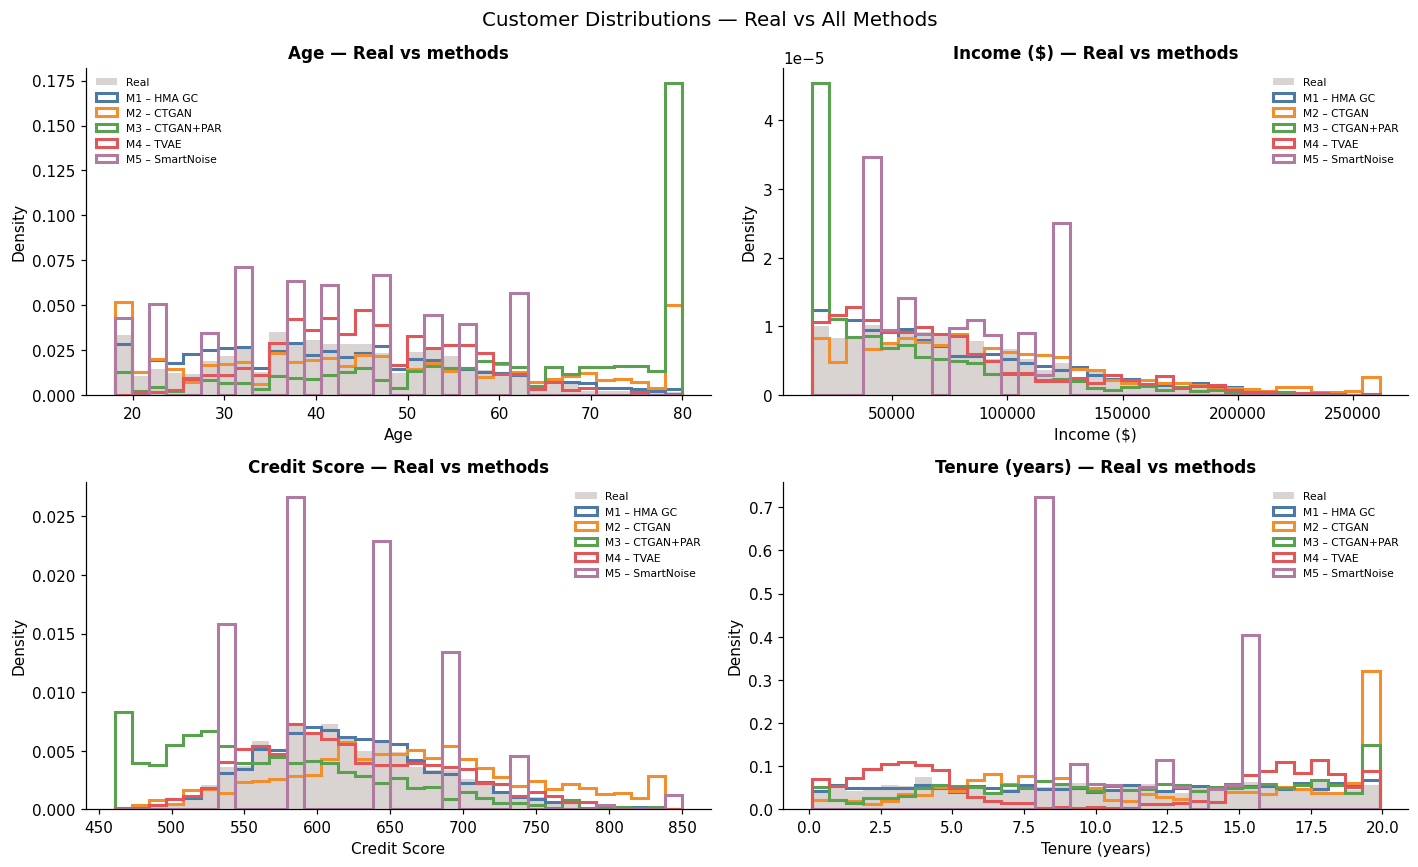

In [16]:
# Per-variable customer distributions — Real (grey fill) vs each method (step outline)
# Separate panels are easier to read/compare than one overlaid strip.
num_cols = [('age', 'Age'), ('income', 'Income ($)'),
            ('credit_score', 'Credit Score'), ('tenure_years', 'Tenure (years)')]
fname = {'age': 'dist_age', 'income': 'dist_income',
         'credit_score': 'dist_credit', 'tenure_years': 'dist_tenure'}

def _plot_dist(ax, col, label, title_size=11, legend_size=7):
    r = df_c[col].dropna()
    all_v = pd.concat([r] + [s['customers'][col].dropna() for s in synthetic_datasets.values()])
    bins = np.linspace(all_v.min(), all_v.max(), 34)
    ax.hist(r, bins=bins, density=True, color=METHOD_COLORS['Real'],
            alpha=0.55, label='Real', edgecolor='none')
    for name, s in synthetic_datasets.items():
        ax.hist(s['customers'][col].dropna(), bins=bins, density=True,
                histtype='step', color=METHOD_COLORS[name], linewidth=2.0, label=name)
    ax.set_title(f'{label} — Real vs methods', fontweight='bold', fontsize=title_size)
    ax.set_xlabel(label); ax.set_ylabel('Density')
    ax.legend(fontsize=legend_size, frameon=False)

# 2x2 grid for the notebook
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, (col, label) in zip(axes.ravel(), num_cols):
    _plot_dist(ax, col, label)
fig.suptitle('Customer Distributions — Real vs All Methods', fontsize=13)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'distributions_all_methods.png', bbox_inches='tight')
plt.show()

# Also save each variable as its own chart (used by the slide deck)
for col, label in num_cols:
    f1, a1 = plt.subplots(figsize=(6.4, 3.7))
    _plot_dist(a1, col, label, title_size=12, legend_size=8)
    f1.tight_layout()
    f1.savefig(REPORTS_DIR / f'{fname[col]}.png', bbox_inches='tight')
    plt.close(f1)

---
## 12  LLM Product Suggestions

Uses the best-performing synthetic dataset to power **DeepSeek** (`deepseek-chat`, OpenAI-compatible) product recommendations. The full product catalog goes in the system prompt and each call adds only the per-customer profile.

> **Requires `DEEPSEEK_API_KEY`** (read from the project `.env`) — cells auto-skip if not set.

In [17]:
import os
from src.llm_suggest import load_env
load_env()  # read DEEPSEEK_API_KEY from project .env

SKIP_LLM = not bool(os.environ.get('DEEPSEEK_API_KEY'))
if SKIP_LLM:
    print('DEEPSEEK_API_KEY not set — LLM cells skipped.')
    print('Add it to .env:  DEEPSEEK_API_KEY=sk-...')
else:
    print('DeepSeek API key found.')
    # Use M1 (HMA + Gaussian Copula) — the recommended method (best customer pair trends)
    best_method = next(m for m in synthetic_datasets if m.startswith('M1'))
    best_s = synthetic_datasets[best_method]
    print(f'Using {best_method} (recommended — customer pair trends={cmp.loc[best_method,"cust_pair_trends"]:.4f})')

DeepSeek API key found.
Using M1 – HMA GC (recommended — customer pair trends=0.7204)


In [18]:
if not SKIP_LLM:
    from src.llm_suggest import suggest
    sample_id = best_s['customers'].iloc[0]['customer_id']
    print(best_s['customers'][best_s['customers']['customer_id']==sample_id][
        ['age','gender','income','occupation','credit_score']].to_string(index=False))
    result = suggest(sample_id, best_s['customers'], best_s['transactions'])
    print(f'\nRecommendations for {sample_id}:')
    for i, rec in enumerate(result['recommendations'], 1):
        print(f'  {i}. [{rec["product_id"]}] {rec["name"]}')
        print(f'     {rec["reason"]}')
    tok = result['cache_tokens']
    print(f'\nTokens — input:{tok["input"]}  cache_create:{tok["cache_creation"]}  cache_read:{tok["cache_read"]}')

 age     gender   income     occupation  credit_score
  42 Non-binary 91388.05 Business Owner           675



Recommendations for C01502:
  1. [P011] Investment Fund A
     Customer has high income and PhD education, likely interested in growing wealth. This low-medium risk investment aligns well with their profile and is not already held.
  2. [P013] Fixed Deposit 1Y
     Customer already holds a basic savings account and has sufficient funds. A 1-year fixed deposit offers low risk and stable returns, complementing their existing banking products.
  3. [P003] Personal Loan
     With a good credit score, steady income, and no existing credit products, a personal loan could help the customer consolidate expenses or invest further, while building credit history.

Tokens — input:705  cache_create:0  cache_read:512


In [19]:
if not SKIP_LLM:
    from src.llm_suggest import batch_suggest
    ids   = best_s['customers'].sample(5, random_state=7)['customer_id'].tolist()
    batch = batch_suggest(ids, best_s['customers'], best_s['transactions'])
    rows  = [{'customer_id': r['customer_id'], 'rank': rk+1,
               'product_id': rec['product_id'], 'name': rec['name'],
               'cache_read': r['cache_tokens']['cache_read']}
             for r in batch if 'error' not in r
             for rk, rec in enumerate(r['recommendations'])]
    recs_df = pd.DataFrame(rows)
    recs_df.to_csv(REPORTS_DIR / 'llm_recommendations.csv', index=False)
    print(recs_df[recs_df['rank']==1][['customer_id','product_id','name','cache_read']].to_string(index=False))

customer_id product_id                  name  cache_read
     C01515       P006     Credit Card Basic         512
     C00133       P001 Basic Savings Account         512
     C00218       P013      Fixed Deposit 1Y         512
     C01817       P003         Personal Loan         512
     C00698       P006     Credit Card Basic         512


---
## 13  Findings & Recommendation

### Results at 1 000 seeds (SDV M1–M4 constraint-fitted · M5 SmartNoise ε=3.0 DP)

| Metric | M1 HMA | M2 CTGAN | M3 PAR | M4 TVAE | M5 SmartNoise | Winner |
|---|---|---|---|---|---|---|
| Overall quality score | 0.851 | 0.840 | 0.544 | 0.826 | **0.887** | **M5** |
| Diagnostic / FK integrity | **1.000** | **1.000** | 0.765 | **1.000** | **1.000** | M1/M2/M4/M5 |
| Cust. column shapes | **0.927** | 0.842 | 0.798 | 0.790 | 0.906 | **M1** |
| Cust. pair trends | **0.720** | 0.544 | 0.540 | 0.683 | 0.680 | **M1** |
| Txn. column shapes | 0.818 | 0.851 | 0.739 | 0.788 | **0.880** | **M5** |
| Cross-table MAD ↓ | 0.242 | 0.281 | **0.195** | 0.288 | 0.297 | **M3** |
| IA KS p-value ↑ | 0.000 | **0.143** | 0.000 | 0.000 | 0.000 | **M2** |
| Autocorr MAE ↓ | 0.076 | 0.063 | 0.124 | 0.022 | **0.005** | **M5** |
| Differential privacy | ✗ | ✗ | ✗ | ✗ | **✓ (ε≈6)** | **M5** |

All methods give 0 orphan FKs and satisfy every business rule (see *Constraint adherence*); only
M3/PAR shows product/category drift (it can't take `FixedCombinations`). M5 enforces the rules by
post-processing its DP output.

---

### SDV vs SmartNoise

**M5 (SmartNoise MST) — best fidelity *and* the only private method.**
The differentially-private synthesizer wins overall quality (0.887), transaction column shapes
(0.880) and autocorrelation (0.005), and is 2nd on customer column shapes (0.906) — all under a
formal (ε, δ)-DP guarantee. Marginal-based DP nails per-column/within-table structure; its one
weakness is **cross-table MAD (0.297, worst)** — it preserves the customer→product signal least
well. *DP costs almost nothing on marginals here, but it isn't free on cross-table correlation.*

**M1 (HMA + Gaussian Copula) — best demographic correlation.**
Leads customer pair trends (0.720), the signal the recommender depends on, ahead of M4/M5 and far
above the GANs. Native FK integrity, no join logic.

**M4 (TVAE) / M2 (CTGAN) — the SDV middle.**
M4: perfect FK + best SDV autocorrelation (0.022), smooth marginals. M2: best transaction timing
(IA KS 0.143) but weakest cross-table correlation among the independents.

**M3 (CTGAN + PAR) — underperforms at this scale.**
Only win is cross-table MAD (0.195); overall quality (0.544) and FK integrity (0.765) lag.

---

### Recommendation

| Priority | Best method | Why |
|---|---|---|
| **Privacy guarantee** | **M5 – SmartNoise** | Formal (ε, δ)-DP; also the best overall fidelity here |
| Customer profile correlations | **M1 – HMA GC** | Best pair trends — the LLM recommender's key signal |
| Simple per-table SDV pipeline | **M4 – TVAE** | Perfect FK, smooth marginals, well-correlated |
| Transaction timing | **M2 – CTGAN** | Only method with a non-trivial inter-arrival KS p-value |
| Cross-table signal | M3 (marginally) | Lowest cross-table MAD, but heavy diagnostic cost |

**Bottom line.** If privacy is a requirement, **M5 (SmartNoise)** is the clear choice — it adds a
DP guarantee at essentially no cost to marginal fidelity (and actually the best overall quality).
If the priority is the demographic→product correlation that drives the recommender, **M1** still
leads. The non-private SDV methods no longer dominate once a DP option is on the table.

---

### External validation

- **MargCTGAN** (Afonja et al., 2023): documents CTGAN's ~57% relative-error cliff at ~640 samples.
- **MST / private-PGM** (McKenna et al., 2021): marginal-based DP synthesis wins the NIST DP synthetic-data challenges — consistent with M5's strong marginal scores here.
- **SDGym benchmarks** (SDV team): statistical models beat GANs on small datasets consistently.
